# Alberta Wildfire RAG / GraphRAG Pipeline

**Goal:** Build a retrieval-augmented generation (RAG) and graph-RAG (GRAG) system over the wildfire reference documents.

**Sections:**
1. Install & configure
2. Load and chunk PDF documents
3. Embedding model grid search (MRR, Precision@k, Recall@k)
4. Save best embedding model + persistent ChromaDB vector store
5. Build Neo4j knowledge graph (documents → chunks → concepts)
6. Agentic RAG/GRAG assistant (ReAct loop)

**Ports used on this system (shared — do not rebind):**
- `11434` — Ollama (local, already running)
- `7687` — Neo4j Bolt (already running)
- `7474` — Neo4j HTTP browser

In [ ]:
%pip install -q chromadb neo4j pypdf python-dotenv tqdm 2>&1 | tail -6

---
## Section 1 — Configuration

In [25]:
import os, json, re, time, textwrap
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from dotenv import load_dotenv
import chromadb
from neo4j import GraphDatabase
from pypdf import PdfReader
from IPython.display import display

load_dotenv(override=True)

# ── Ollama (local instance on port 11434 — do not change port) ──────────────
OLLAMA_LOCAL_URL = os.getenv("OLLAMA_LOCAL_URL", "http://localhost:11434")

# ── Neo4j (existing instance on port 7687 — do not rebind) ──────────────────
NEO4J_URI      = os.getenv("NEO4J_URI",      "bolt://localhost:7687")
NEO4J_USER     = os.getenv("NEO4J_USER",     "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DOCS_DIR    = Path("docs/data_docs")
VECTOR_STORE_DIR = Path("vector_store")
RESULTS_DIR      = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# ── Embedding models to evaluate (all confirmed present on local Ollama) ─────
EMBEDDING_MODELS = [
    "nomic-embed-text:latest",
    "mxbai-embed-large:latest",
    "bge-large:latest",
    "snowflake-arctic-embed:latest",
    "snowflake-arctic-embed2:latest",
    "granite-embedding:latest",
    "embeddinggemma:latest",
]

# ── Grid search k values ─────────────────────────────────────────────────────
K_VALUES = [1, 3, 5, 10]

# ── LLM for the agent (local, no new ports needed) ───────────────────────────
AGENT_LLM = "llama3.1:8b"   # change to llama3.2:3b for speed, llama3:70b for quality

print(f"Ollama local : {OLLAMA_LOCAL_URL}")
print(f"Neo4j Bolt   : {NEO4J_URI}")
print(f"Data docs    : {DATA_DOCS_DIR}")
print(f"PDF files    : {[p.name for p in sorted(DATA_DOCS_DIR.glob('*.pdf'))]}")


Ollama local : http://localhost:11434
Neo4j Bolt   : bolt://localhost:7687
Data docs    : docs/data_docs
PDF files    : ['7032001-2013-11-firesmart-guidebook-community-protection-guidebook-wildland-urban.pdf', 'CWFIS_DataServices_HowtoAccessDailyMaps&DataLayers.pdf', 'af-farm-and-acreage-guide-to-reducing-wildfire-risk-2020-08-25.pdf', 'alberta-wildland-urban-interface-fires.pdf', 'p-310-09-ho1-prevention-plan-template.pdf', 'rmrs_gtr292.pdf']


In [14]:
# ── Verify Ollama is reachable on local port 11434 ───────────────────────────
def list_ollama_models(base_url: str = OLLAMA_LOCAL_URL) -> List[str]:
    resp = requests.get(f"{base_url}/api/tags", timeout=10)
    resp.raise_for_status()
    return [m["name"] for m in resp.json().get("models", [])]

try:
    all_models = list_ollama_models()
    embed_available = [m for m in EMBEDDING_MODELS if m in all_models]
    print(f"Ollama reachable — {len(all_models)} models available")
    print(f"Embedding models confirmed ({len(embed_available)}/{len(EMBEDDING_MODELS)}):")
    for m in embed_available:
        print(f"  ✓ {m}")
    missing = [m for m in EMBEDDING_MODELS if m not in all_models]
    if missing:
        print(f"\nNot found (will be skipped): {missing}")
    EMBEDDING_MODELS = embed_available  # only test what's actually present
except Exception as e:
    print(f"ERROR: Could not reach Ollama at {OLLAMA_LOCAL_URL}\n{e}")

Ollama reachable — 42 models available
Embedding models confirmed (7/7):
  ✓ nomic-embed-text:latest
  ✓ mxbai-embed-large:latest
  ✓ bge-large:latest
  ✓ snowflake-arctic-embed:latest
  ✓ snowflake-arctic-embed2:latest
  ✓ granite-embedding:latest
  ✓ embeddinggemma:latest


---
## Section 2 — Load and Chunk PDF Documents

In [26]:
def extract_pdf_text(pdf_path: Path) -> List[Dict]:
    """Extract text page-by-page from a PDF."""
    reader = PdfReader(str(pdf_path))
    pages = []
    for i, page in enumerate(reader.pages):
        text = page.extract_text() or ""
        text = re.sub(r'\s+', ' ', text).strip()
        if len(text) > 30:
            pages.append({"page": i + 1, "text": text})
    return pages


def chunk_pages(pages: List[Dict], chunk_words: int = 350, overlap_words: int = 70) -> List[str]:
    """Sliding-window word-level chunker over concatenated page text."""
    full_text = " ".join(p["text"] for p in pages)
    words = full_text.split()
    chunks = []
    step = chunk_words - overlap_words
    for start in range(0, len(words), step):
        chunk = " ".join(words[start : start + chunk_words])
        if len(chunk.split()) >= 25:          # skip tiny tail chunks
            chunks.append(chunk)
    return chunks


# ── Load all PDFs ─────────────────────────────────────────────────────────────
all_chunks: List[Dict] = []          # {id, text, source, doc_title}
pdf_files = sorted(DATA_DOCS_DIR.glob("*.pdf"))

for pdf_path in pdf_files:
    pages = extract_pdf_text(pdf_path)
    chunks = chunk_pages(pages)
    doc_title = pdf_path.stem[:80]
    for i, chunk in enumerate(chunks):
        all_chunks.append({
            "id":        f"{pdf_path.stem[:40]}__c{i:04d}",
            "text":      chunk,
            "source":    str(pdf_path),
            "doc_title": doc_title,
        })
    print(f"  {pdf_path.name[:60]:<60}  {len(pages):>4} pages  →  {len(chunks):>4} chunks")

print(f"\nTotal chunks: {len(all_chunks)}")

  7032001-2013-11-firesmart-guidebook-community-protection-gui    85 pages  →    66 chunks
  CWFIS_DataServices_HowtoAccessDailyMaps&DataLayers.pdf           4 pages  →     4 chunks
  af-farm-and-acreage-guide-to-reducing-wildfire-risk-2020-08-    21 pages  →    32 chunks
  alberta-wildland-urban-interface-fires.pdf                      30 pages  →    22 chunks
  p-310-09-ho1-prevention-plan-template.pdf                        4 pages  →     7 chunks
  rmrs_gtr292.pdf                                                342 pages  →   411 chunks

Total chunks: 542


In [27]:

# ── Save chunks to disk immediately after extraction ─────────────────────────
CHUNKS_FILE = RESULTS_DIR / "all_chunks.json"
with open(CHUNKS_FILE, "w") as f:
    json.dump(all_chunks, f, indent=2)
print(f"Saved {len(all_chunks)} chunks → {CHUNKS_FILE}")

# ── Reload helper (run this in any cell after a kernel restart) ───────────────
def load_chunks() -> List[Dict]:
    with open(RESULTS_DIR / "all_chunks.json") as f:
        return json.load(f)


Saved 542 chunks → results/all_chunks.json


In [28]:
# Preview a random chunk
import random
sample = random.choice(all_chunks)
print(f"Doc   : {sample['doc_title']}")
print(f"ID    : {sample['id']}")
print(f"Words : {len(sample['text'].split())}")
print()
print(textwrap.fill(sample['text'][:600], width=90))

Doc   : rmrs_gtr292
ID    : rmrs_gtr292__c0169
Words : 350

Manager comment: Although there are places for targeted treatment planning with single
objectives, integrated fuel treatments help to develop an awareness and understanding of
complimentary and contradictory resource objectives and the need to develop prescriptions
that best harmonize them. Silviculture is founded on the basic science and life history of
forests. The practice is designed to integrate forest ecology and silvics (scientific
study of trees and their environment) in order to develop treatment pathways over time and
space (a silvicultural system) that influence vegetation growth an


---
## Section 3 — Embedding Model Grid Search

### Evaluation methodology
We construct **synthetic queries** without manual labelling:
- For each sampled chunk, the **first 40 words** become the query.
- The **ground-truth relevant document** is that same chunk (index in the corpus).
- We embed the full corpus and all queries, compute cosine similarity, rank, then report:
  - **MRR** — Mean Reciprocal Rank of the correct chunk
  - **Precision@k** — fraction of top-k results that are relevant (binary: 0 or 1/k)
  - **Recall@k** — whether the correct chunk appears in top-k (0 or 1)

> Random baseline MRR ≈ 1/|corpus|. A good embedding model should be >> 0.5.

In [30]:

# ── Embedding helper ──────────────────────────────────────────────────────────
# All 7 Ollama embedding models on this server support the batch /api/embed
# endpoint.  The ONLY caveat is that the FIRST call for a model may be slow
# (30-90s) because Ollama must load the model weights into GPU/RAM.
#
# Strategy:
#   • Use /api/embed exclusively  ({"input": [...]}) → {"embeddings": [...]}
#   • First call per model gets a generous 180s timeout (cold-load).
#   • Subsequent batches use 120s timeout.
#   • A separate warm_up_models() helper pre-loads all models before the
#     timed grid search so load time doesn't skew metrics.

_warmed_models: set = set()          # models that have been pre-loaded
EMBED_BATCH_SIZE = 16                # texts per request


def warm_up_model(model: str, base_url: str = None) -> bool:
    """Send a single probe to force Ollama to load the model (cold-start)."""
    base_url = base_url or OLLAMA_LOCAL_URL
    label = model.split(":")[0]
    try:
        resp = requests.post(
            f"{base_url}/api/embed",
            json={"model": model, "input": ["warmup"]},
            timeout=180,           # generous — first load can take 30-90s
        )
        resp.raise_for_status()
        data = resp.json()
        if "embeddings" in data and data["embeddings"]:
            dim = len(data["embeddings"][0])
            _warmed_models.add(model)
            print(f"  ✓ {label:<30} dim={dim}")
            return True
    except Exception as e:
        print(f"  ✗ {label:<30} FAILED — {e}")
    return False


def warm_up_models(models: List[str], base_url: str = None) -> List[str]:
    """Pre-load all models into Ollama memory.  Returns list of working models."""
    base_url = base_url or OLLAMA_LOCAL_URL
    print("Warming up embedding models (first load can take 30-90s each)...")
    working = []
    for m in models:
        if warm_up_model(m, base_url):
            working.append(m)
    print(f"\n{len(working)}/{len(models)} models ready.\n")
    return working


def embed_texts(
    texts: List[str],
    model: str,
    base_url: str = None,
    batch_size: int = EMBED_BATCH_SIZE,
    show_progress: bool = False,
) -> np.ndarray:
    """
    Embed a list of texts via Ollama /api/embed (batch endpoint).
    Returns (N, dim) float32 array.
    """
    base_url = base_url or OLLAMA_LOCAL_URL
    label = model.split(":")[0][:24]

    # If model hasn't been warmed up yet, do it now
    if model not in _warmed_models:
        print(f"    [{label}] loading model (first call) ...", flush=True)
        warm_up_model(model, base_url)

    batches = [texts[i : i + batch_size] for i in range(0, len(texts), batch_size)]
    all_embs: List[List[float]] = []

    pbar = tqdm(batches, desc=f"{label}", unit="batch",
                disable=not show_progress, leave=False)
    for batch in pbar:
        resp = requests.post(
            f"{base_url}/api/embed",
            json={"model": model, "input": batch},
            timeout=120,
        )
        resp.raise_for_status()
        all_embs.extend(resp.json()["embeddings"])

    return np.array(all_embs, dtype=np.float32)


# ── Evaluation functions ──────────────────────────────────────────────────────
def cosine_sim(q_vecs: np.ndarray, d_vecs: np.ndarray) -> np.ndarray:
    q = q_vecs / (np.linalg.norm(q_vecs, axis=1, keepdims=True) + 1e-9)
    d = d_vecs / (np.linalg.norm(d_vecs, axis=1, keepdims=True) + 1e-9)
    return q @ d.T


def retrieval_metrics(
    query_vecs: np.ndarray,
    doc_vecs: np.ndarray,
    relevant_indices: List[int],
    k_values: List[int],
) -> Dict[str, float]:
    """Compute MRR and Precision/Recall@k."""
    sim   = cosine_sim(query_vecs, doc_vecs)
    ranks = np.argsort(-sim, axis=1)

    mrr_scores = []
    for i, rel in enumerate(relevant_indices):
        pos = np.where(ranks[i] == rel)[0]
        mrr_scores.append(1.0 / (pos[0] + 1) if len(pos) else 0.0)

    out = {"MRR": float(np.mean(mrr_scores))}
    for k in k_values:
        hits = [1 if rel in set(ranks[i, :k]) else 0 for i, rel in enumerate(relevant_indices)]
        out[f"P@{k}"] = float(np.mean([h / k for h in hits]))
        out[f"R@{k}"] = float(np.mean(hits))
    return out


_warmed_models = set()   # reset on cell re-run
print("embed_texts ready  (batch API only, 120s timeout, warm-up available)")


embed_texts ready  (batch API only, 120s timeout, warm-up available)


In [31]:

# ── Build evaluation corpus and query set ─────────────────────────────────────
# Grid search embeds a SUBSAMPLE (150 chunks) — fast, still statistically valid.
# The full corpus is embedded once in Section 4 with the winning model only.
#
# Evaluation design:
#   eval_corpus[i] = a randomly sampled chunk
#   eval_queries[i] = first 40 words of eval_corpus[i]   (synthetic query)
#   ground truth    = query i should retrieve eval_corpus[i]  (index = i)

np.random.seed(42)
GRID_EVAL_N = min(150, len(all_chunks))    # subsample size for grid search
eval_idx    = np.random.choice(len(all_chunks), GRID_EVAL_N, replace=False)

eval_corpus_texts = [all_chunks[i]["text"] for i in eval_idx]
eval_queries      = [" ".join(all_chunks[i]["text"].split()[:40]) for i in eval_idx]
eval_relevant_idx = list(range(GRID_EVAL_N))   # query i → position i in eval_corpus

corpus_texts = [c["text"] for c in all_chunks]   # full corpus — used in Section 4 only

print(f"Full corpus      : {len(corpus_texts)} chunks  (Section 4)")
print(f"Grid eval corpus : {len(eval_corpus_texts)} sampled chunks  (Section 3)")
print(f"Query set        : {len(eval_queries)} synthetic queries")
print(f"k values         : {K_VALUES}")
print()
print(f"Example query →  '{eval_queries[0][:80]}...'")


Full corpus      : 542 chunks  (Section 4)
Grid eval corpus : 150 sampled chunks  (Section 3)
Query set        : 150 synthetic queries
k values         : [1, 3, 5, 10]

Example query →  'be used in any season, given the right conditions. This type of fire tends to de...'


In [33]:

# ── Grid Search ───────────────────────────────────────────────────────────────
# Step 0 : warm up ALL models (force Ollama to load them — up to 180s each).
# Step 1 : embed 150-chunk eval corpus per model (timed).
# Step 2 : embed 150 queries per model.
# Step 3 : compute MRR, P@k, R@k.

grid_results: List[Dict] = []
_warmed_models = set()   # fresh state for this run

# ── Warm-up phase (NOT timed — cold loads can take 30-90s) ───────────────────
working_models = warm_up_models(EMBEDDING_MODELS)

if not working_models:
    raise RuntimeError("No embedding models could be loaded — check Ollama at "
                       f"{OLLAMA_LOCAL_URL}")

# ── Evaluate each warmed model ────────────────────────────────────────────────
for model in working_models:
    label = model.split(":")[0]
    print(f"\n{'─'*70}")
    print(f"Model : {model}")
    t0 = time.time()
    try:
        print(f"  Embedding {len(eval_corpus_texts)} corpus chunks ...")
        doc_vecs = embed_texts(eval_corpus_texts, model=model, show_progress=True)
        print(f"  ✓ corpus  shape={doc_vecs.shape}")

        print(f"  Embedding {len(eval_queries)} queries ...")
        q_vecs = embed_texts(eval_queries, model=model, show_progress=True)
        print(f"  ✓ queries done")

        metrics = retrieval_metrics(
            q_vecs, doc_vecs,
            relevant_indices=eval_relevant_idx,
            k_values=K_VALUES,
        )
        elapsed = time.time() - t0
        row = {"model": model, "dim": int(doc_vecs.shape[1]),
               "time_s": round(elapsed, 1), **metrics}
        grid_results.append(row)
        for key, val in metrics.items():
            print(f"    {key:<8}: {val:.4f}")
        print(f"    ⏱ {elapsed:.1f}s")

    except Exception as e:
        elapsed = time.time() - t0
        print(f"  ✗ ERROR after {elapsed:.1f}s: {e}")
        import traceback; traceback.print_exc()
        grid_results.append({"model": model, "error": str(e)})

print(f"\n\n{'═'*70}")
print(f"Grid search complete — {len([r for r in grid_results if 'MRR' in r])}/{len(working_models)} models evaluated successfully.")


Warming up embedding models (first load can take 30-90s each)...
  ✓ nomic-embed-text               dim=768
  ✓ mxbai-embed-large              dim=1024
  ✓ bge-large                      dim=1024
  ✓ snowflake-arctic-embed         dim=1024
  ✓ snowflake-arctic-embed2        dim=1024
  ✓ granite-embedding              dim=384
  ✓ embeddinggemma                 dim=768

7/7 models ready.


──────────────────────────────────────────────────────────────────────
Model : nomic-embed-text:latest
  Embedding 150 corpus chunks ...


Traceback (most recent call last):                                 
  File "/tmp/ipykernel_3005323/403125163.py", line 25, in <module>
    doc_vecs = embed_texts(eval_corpus_texts, model=model, show_progress=True)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_3005323/711669426.py", line 81, in embed_texts
    resp.raise_for_status()
  File "/home/emma/get_repos/EMBER-Alberta-Wildfires/firevenv/lib/python3.12/site-packages/requests/models.py", line 1028, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 400 Client Error: Bad Request for url: http://localhost:11434/api/embed


  ✗ ERROR after 0.7s: 400 Client Error: Bad Request for url: http://localhost:11434/api/embed

──────────────────────────────────────────────────────────────────────
Model : mxbai-embed-large:latest
  Embedding 150 corpus chunks ...


Traceback (most recent call last):                          
  File "/tmp/ipykernel_3005323/403125163.py", line 25, in <module>
    doc_vecs = embed_texts(eval_corpus_texts, model=model, show_progress=True)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_3005323/711669426.py", line 81, in embed_texts
    resp.raise_for_status()
  File "/home/emma/get_repos/EMBER-Alberta-Wildfires/firevenv/lib/python3.12/site-packages/requests/models.py", line 1028, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 400 Client Error: Bad Request for url: http://localhost:11434/api/embed


  ✗ ERROR after 0.3s: 400 Client Error: Bad Request for url: http://localhost:11434/api/embed

──────────────────────────────────────────────────────────────────────
Model : bge-large:latest
  Embedding 150 corpus chunks ...


...

  ✓ queries done
    MRR     : 0.8703
    P@1     : 0.7933
    R@1     : 0.7933
    P@3     : 0.3156
    R@3     : 0.9467
    P@5     : 0.1933
    R@5     : 0.9667
    P@10    : 0.0987
    R@10    : 0.9867
    ⏱ 8.4s

──────────────────────────────────────────────────────────────────────
Model : granite-embedding:latest
  Embedding 150 corpus chunks ...


Traceback (most recent call last):                                  
  File "/tmp/ipykernel_3005323/403125163.py", line 25, in <module>
    doc_vecs = embed_texts(eval_corpus_texts, model=model, show_progress=True)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_3005323/711669426.py", line 81, in embed_texts
    resp.raise_for_status()
  File "/home/emma/get_repos/EMBER-Alberta-Wildfires/firevenv/lib/python3.12/site-packages/requests/models.py", line 1028, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 400 Client Error: Bad Request for url: http://localhost:11434/api/embed


  ✗ ERROR after 2.2s: 400 Client Error: Bad Request for url: http://localhost:11434/api/embed

──────────────────────────────────────────────────────────────────────
Model : embeddinggemma:latest
  Embedding 150 corpus chunks ...


  ✓ corpus  shape=(150, 768)
  Embedding 150 queries ...


  ✓ queries done
    MRR     : 0.9307
    P@1     : 0.8800
    R@1     : 0.8800
    P@3     : 0.3289
    R@3     : 0.9867
    P@5     : 0.1973
    R@5     : 0.9867
    P@10    : 0.1000
    R@10    : 1.0000
    ⏱ 10.3s


══════════════════════════════════════════════════════════════════════
Grid search complete — 2/7 models evaluated successfully.


=== Full Results ===


,dim,time_s,MRR,P@1,R@1,P@3,R@3,P@5,R@5,P@10,R@10
model,,,,,,,,,,,
snowflake-arctic-embed2:latest,1024.0,8.4,0.8703,0.7933,0.7933,0.3156,0.9467,0.1933,0.9667,0.0987,0.9867
embeddinggemma:latest,768.0,10.3,0.9307,0.8800,0.8800,0.3289,0.9867,0.1973,0.9867,0.1000,1.0000



★ Best model : embeddinggemma:latest
  MRR       : 0.9307
  P@5       : 0.1973
  R@5       : 0.9867
  Dim       : 768

Saved: results/embedding_grid_search.csv


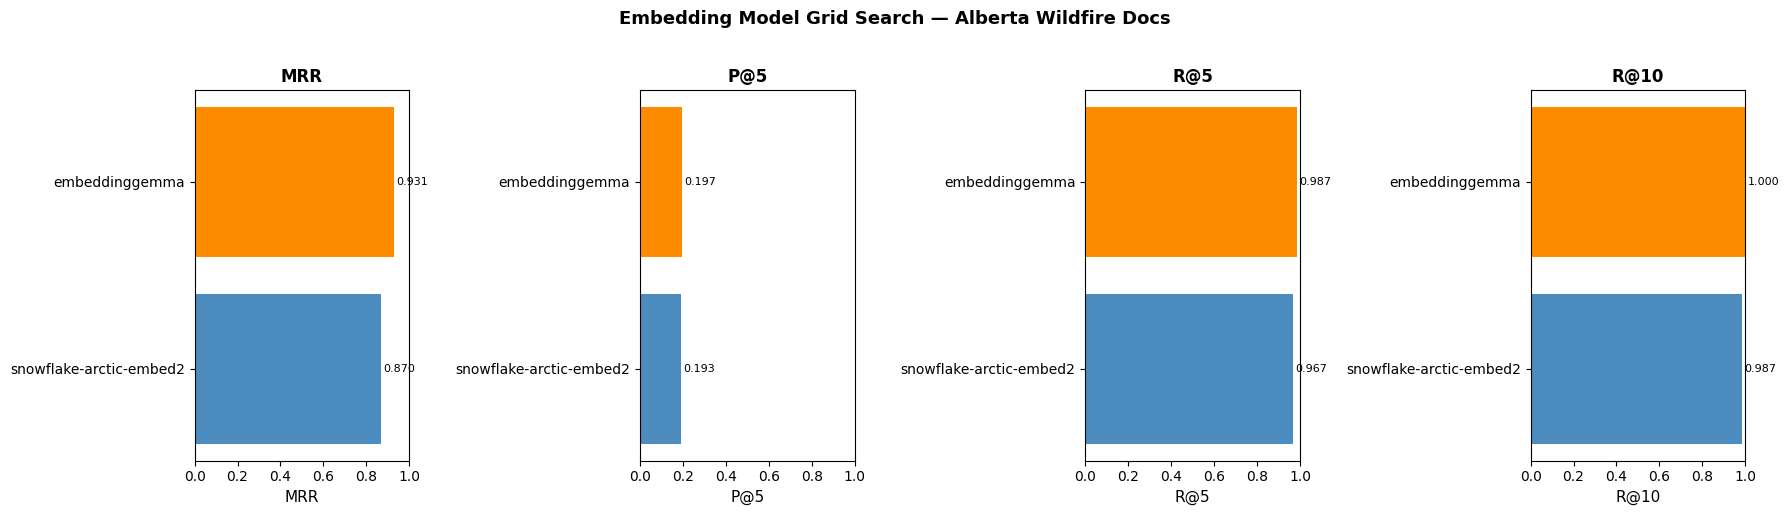

Saved: results/embedding_grid_search.png


In [34]:
# ── Analyse results ───────────────────────────────────────────────────────────
grid_df = pd.DataFrame(grid_results)
valid_df = grid_df.dropna(subset=["MRR"]).copy()

print("=== Full Results ===")
display(valid_df.set_index("model").drop(columns=["error"], errors="ignore").round(4))

# ── Pick best model (MRR primary, P@5 tiebreak) ───────────────────────────────
best_row  = valid_df.sort_values(["MRR", "P@5"], ascending=False).iloc[0]
BEST_MODEL = best_row["model"]
BEST_DIM   = int(best_row["dim"]) if "dim" in best_row else None

print(f"\n★ Best model : {BEST_MODEL}")
print(f"  MRR       : {best_row['MRR']:.4f}")
print(f"  P@5       : {best_row['P@5']:.4f}")
print(f"  R@5       : {best_row['R@5']:.4f}")
print(f"  Dim       : {BEST_DIM}")

# Save raw results
grid_df.to_csv(RESULTS_DIR / "embedding_grid_search.csv", index=False)
print("\nSaved: results/embedding_grid_search.csv")

# ── Plot ──────────────────────────────────────────────────────────────────────
metrics_plot = ["MRR", "P@5", "R@5", "R@10"]
metrics_plot = [m for m in metrics_plot if m in valid_df.columns]
ncols = len(metrics_plot)
fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 5))
if ncols == 1:
    axes = [axes]

model_labels = valid_df["model"].str.replace(":latest", "", regex=False)
colors = ["#FF8C00" if m == BEST_MODEL else "#4C8CBF" for m in valid_df["model"]]

for ax, metric in zip(axes, metrics_plot):
    bars = ax.barh(model_labels, valid_df[metric], color=colors)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, valid_df[metric]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)

fig.suptitle("Embedding Model Grid Search — Alberta Wildfire Docs",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "embedding_grid_search.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/embedding_grid_search.png")

---
## Section 4 — Build & Save Vector Store

In [35]:
# ── Re-embed full corpus with best model ─────────────────────────────────────
print(f"Embedding {len(corpus_texts)} chunks with best model: {BEST_MODEL}")
best_vecs = embed_texts(corpus_texts, model=BEST_MODEL, show_progress=True)
print(f"Done. Shape: {best_vecs.shape}")

# Save embeddings as numpy array (fast reload for Neo4j section)
np.save(RESULTS_DIR / "best_embeddings.npy", best_vecs)
print(f"Saved: results/best_embeddings.npy")

Embedding 542 chunks with best model: embeddinggemma:latest


Done. Shape: (542, 768)
Saved: results/best_embeddings.npy


In [36]:
# ── Build persistent ChromaDB vector store ────────────────────────────────────
VECTOR_STORE_DIR.mkdir(exist_ok=True)
chroma_client = chromadb.PersistentClient(path=str(VECTOR_STORE_DIR))

# Drop + recreate to allow re-runs
try:
    chroma_client.delete_collection("wildfire_docs")
    print("Dropped existing 'wildfire_docs' collection.")
except Exception:
    pass

collection = chroma_client.create_collection(
    name="wildfire_docs",
    metadata={"hnsw:space": "cosine"},
)

# Add in batches
BATCH = 500
for i in range(0, len(all_chunks), BATCH):
    batch = all_chunks[i : i + BATCH]
    collection.add(
        ids        = [c["id"]       for c in batch],
        embeddings = best_vecs[i : i + BATCH].tolist(),
        documents  = [c["text"]     for c in batch],
        metadatas  = [{"source": c["source"], "doc_title": c["doc_title"]} for c in batch],
    )
    print(f"  Indexed {min(i + BATCH, len(all_chunks)):>5} / {len(all_chunks)}")

print(f"\nVector store persisted to: {VECTOR_STORE_DIR}")
print(f"Collection count: {collection.count()}")

  Indexed   500 / 542
  Indexed   542 / 542

Vector store persisted to: vector_store
Collection count: 542


In [37]:
# ── Save RAG configuration ────────────────────────────────────────────────────
rag_config = {
    "best_embedding_model":  BEST_MODEL,
    "embedding_dim":         int(best_vecs.shape[1]),
    "ollama_local_url":      OLLAMA_LOCAL_URL,
    "vector_store_path":     str(VECTOR_STORE_DIR),
    "chroma_collection":     "wildfire_docs",
    "total_chunks":          len(all_chunks),
    "pdf_files":             [p.name for p in pdf_files],
    "grid_search_summary":   grid_results,
}

with open(RESULTS_DIR / "rag_config.json", "w") as f:
    json.dump(rag_config, f, indent=2)

print("Saved: results/rag_config.json")
print(json.dumps({k: v for k, v in rag_config.items() if k != "grid_search_summary"}, indent=2))

Saved: results/rag_config.json
{
  "best_embedding_model": "embeddinggemma:latest",
  "embedding_dim": 768,
  "ollama_local_url": "http://localhost:11434",
  "vector_store_path": "vector_store",
  "chroma_collection": "wildfire_docs",
  "total_chunks": 542,
  "pdf_files": [
    "7032001-2013-11-firesmart-guidebook-community-protection-guidebook-wildland-urban.pdf",
    "CWFIS_DataServices_HowtoAccessDailyMaps&DataLayers.pdf",
    "af-farm-and-acreage-guide-to-reducing-wildfire-risk-2020-08-25.pdf",
    "alberta-wildland-urban-interface-fires.pdf",
    "p-310-09-ho1-prevention-plan-template.pdf",
    "rmrs_gtr292.pdf"
  ]
}


---
## Section 5 — Neo4j Knowledge Graph

Connects to the **existing** Neo4j instance on `bolt://localhost:7687`.

> **Before running:** set `NEO4J_PASSWORD` in `.env` to match your Neo4j credentials.

Graph schema:
```
(Document)-[:CONTAINS]->(Chunk)-[:MENTIONS]->(Concept)
(Concept)-[:RELATED_TO]->(Concept)      ← co-occurrence in same chunk
```
Chunks also carry an `embedding` property for Neo4j vector index search.

In [38]:
# ── Connect to existing Neo4j (port 7687) ─────────────────────────────────────
neo4j_driver = None
try:
    neo4j_driver = GraphDatabase.driver(
        NEO4J_URI,
        auth=(NEO4J_USER, NEO4J_PASSWORD),
    )
    neo4j_driver.verify_connectivity()
    print(f"✓ Neo4j connected: {NEO4J_URI}")
except Exception as e:
    print(f"✗ Neo4j connection failed: {e}")
    print("  → Update NEO4J_PASSWORD in .env and re-run this cell.")
    print("  → Sections 5 & 6-GRAG will be skipped; RAG-only assistant still works.")


def run_cypher(query: str, params: dict = {}) -> list:
    if neo4j_driver is None:
        raise RuntimeError("Neo4j not connected.")
    with neo4j_driver.session() as session:
        return [dict(r) for r in session.run(query, params)]

✗ Neo4j connection failed: {neo4j_code: Neo.ClientError.Security.Unauthorized} {message: The client is unauthorized due to authentication failure.} {gql_status: 50N42} {gql_status_description: error: general processing exception - unexpected error. Unexpected error has occurred. See debug log for details.}
  → Update NEO4J_PASSWORD in .env and re-run this cell.
  → Sections 5 & 6-GRAG will be skipped; RAG-only assistant still works.


In [4]:
if neo4j_driver:
    # ── Schema constraints ────────────────────────────────────────────────────
    schema_stmts = [
        "CREATE CONSTRAINT ember_doc_title IF NOT EXISTS FOR (d:Document) REQUIRE d.title IS UNIQUE",
        "CREATE CONSTRAINT ember_chunk_id  IF NOT EXISTS FOR (c:Chunk)    REQUIRE c.chunk_id IS UNIQUE",
        "CREATE CONSTRAINT ember_concept   IF NOT EXISTS FOR (co:Concept) REQUIRE co.name IS UNIQUE",
    ]
    for stmt in schema_stmts:
        try:
            run_cypher(stmt)
        except Exception as e:
            print(f"  Schema note: {e}")

    # ── Clean EMBER data to allow re-runs without duplicates ──────────────────
    run_cypher("MATCH (n) WHERE n.project = 'EMBER' DETACH DELETE n")
    print("Cleared previous EMBER nodes.")

    # ── Document nodes ────────────────────────────────────────────────────────
    for pdf_path in pdf_files:
        run_cypher(
            """
            MERGE (d:Document {title: $title})
            SET d.path = $path, d.project = 'EMBER', d.source = 'data_docs'
            """,
            {"title": pdf_path.stem[:80], "path": str(pdf_path)},
        )
    print(f"Created {len(pdf_files)} Document nodes.")

    # ── Chunk nodes + CONTAINS relationships ──────────────────────────────────
    print(f"Creating {len(all_chunks)} Chunk nodes ...")
    BATCH = 200
    for i in range(0, len(all_chunks), BATCH):
        batch = all_chunks[i : i + BATCH]
        run_cypher(
            """
            UNWIND $chunks AS c
            MERGE (ch:Chunk {chunk_id: c.id})
            SET ch.text      = c.text,
                ch.doc_title = c.doc_title,
                ch.project   = 'EMBER'
            WITH ch, c
            MATCH (d:Document {title: c.doc_title})
            MERGE (d)-[:CONTAINS]->(ch)
            """,
            {"chunks": batch},
        )
        print(f"  {min(i + BATCH, len(all_chunks)):>5} / {len(all_chunks)}")

    print("Chunk nodes created.")

NameError: name 'neo4j_driver' is not defined

In [5]:
if neo4j_driver:
    # ── Attach embeddings to Chunk nodes ─────────────────────────────────────
    # Load from saved file if best_vecs is not in memory
    if "best_vecs" not in dir() or best_vecs is None:
        best_vecs = np.load(RESULTS_DIR / "best_embeddings.npy")
    with open(RESULTS_DIR / "rag_config.json") as f:
        cfg = json.load(f)
    BEST_DIM = cfg["embedding_dim"]

    print(f"Attaching {len(all_chunks)} embeddings (dim={BEST_DIM}) to Chunk nodes ...")
    BATCH = 100
    for i in range(0, len(all_chunks), BATCH):
        batch_data = [
            {"id": all_chunks[j]["id"], "emb": best_vecs[j].tolist()}
            for j in range(i, min(i + BATCH, len(all_chunks)))
        ]
        run_cypher(
            """
            UNWIND $rows AS r
            MATCH (c:Chunk {chunk_id: r.id})
            SET c.embedding = r.emb
            """,
            {"rows": batch_data},
        )
        if (i // BATCH) % 5 == 0:
            print(f"  {min(i + BATCH, len(all_chunks)):>5} / {len(all_chunks)}")

    # ── Neo4j vector index (Neo4j 5.x) ───────────────────────────────────────
    try:
        run_cypher(
            f"""
            CREATE VECTOR INDEX ember_chunk_vectors IF NOT EXISTS
            FOR (c:Chunk) ON (c.embedding)
            OPTIONS {{indexConfig: {{
                `vector.dimensions`: {BEST_DIM},
                `vector.similarity_function`: 'cosine'
            }}}}
            """
        )
        print(f"Vector index 'ember_chunk_vectors' created (dim={BEST_DIM}).")
    except Exception as e:
        print(f"Vector index note (may already exist or Neo4j < 5.x): {e}")

NameError: name 'neo4j_driver' is not defined

In [6]:
if neo4j_driver:
    # ── Domain concepts for the wildfire knowledge graph ─────────────────────
    WILDFIRE_CONCEPTS = [
        ("Large Fire",               "Classification"),
        ("AUPRC",                    "Metric"),
        ("AUROC",                    "Metric"),
        ("Random Forest",            "Model"),
        ("Logistic Regression",      "Model"),
        ("Isolation Forest",         "Model"),
        ("SMOTE",                    "Technique"),
        ("SHAP",                     "Technique"),
        ("assessment hectares",      "Feature"),
        ("spread rate",              "Feature"),
        ("wind speed",               "Feature"),
        ("lightning",                "Cause"),
        ("prescribed fire",          "Technique"),
        ("FireSmart",                "Program"),
        ("Wildland-Urban Interface", "Concept"),
        ("fire weather index",       "Index"),
        ("CWFIS",                    "Dataset"),
        ("fire behaviour",           "Concept"),
        ("fuel management",          "Technique"),
        ("evacuation",               "Procedure"),
        ("Alberta Forest Protection","Organization"),
        ("fire suppression",         "Procedure"),
        ("detection lag",            "Feature"),
        ("dispatch lag",             "Feature"),
        ("Size Class D",             "Classification"),
        ("Size Class E",             "Classification"),
    ]

    # Create Concept nodes
    for name, ctype in WILDFIRE_CONCEPTS:
        run_cypher(
            "MERGE (c:Concept {name: $name}) SET c.type = $type, c.project = 'EMBER'",
            {"name": name, "type": ctype},
        )
    print(f"Created {len(WILDFIRE_CONCEPTS)} Concept nodes.")

    # Link Chunks → Concepts (text match)
    print("Linking chunks to concepts ...")
    for name, _ in tqdm(WILDFIRE_CONCEPTS):
        run_cypher(
            """
            MATCH (ch:Chunk {project: 'EMBER'}), (co:Concept {name: $name})
            WHERE toLower(ch.text) CONTAINS toLower($name)
            MERGE (ch)-[:MENTIONS]->(co)
            """,
            {"name": name},
        )

    # Co-occurrence → RELATED_TO
    run_cypher(
        """
        MATCH (c1:Concept)<-[:MENTIONS]-(ch:Chunk)-[:MENTIONS]->(c2:Concept)
        WHERE id(c1) < id(c2)
        MERGE (c1)-[:RELATED_TO]->(c2)
        """
    )
    print("Concept relationships created.")

    # ── Verify graph ──────────────────────────────────────────────────────────
    print("\n── Graph Summary ──")
    for label in ["Document", "Chunk", "Concept"]:
        n = run_cypher(f"MATCH (n:{label} {{project:'EMBER'}}) RETURN count(n) AS c")[0]["c"]
        print(f"  {label:<12}: {n}")
    for rel in ["CONTAINS", "MENTIONS", "RELATED_TO"]:
        n = run_cypher(
            f"MATCH (a {{project:'EMBER'}})-[r:{rel}]->(b) RETURN count(r) AS c"
        )[0]["c"]
        print(f"  :{rel:<14}: {n}")

NameError: name 'neo4j_driver' is not defined

---
## Section 6 — Agentic RAG / GRAG Assistant

A **ReAct** (Reason + Act) agent loop that can:
| Tool | Type | What it does |
|---|---|---|
| `rag_retrieve` | RAG | Cosine search over ChromaDB vector store |
| `grag_vector_search` | GRAG | Neo4j vector index search (semantic) |
| `grag_concept_neighbors` | GRAG | Graph traversal from a concept |
| `grag_concept_chunks` | GRAG | Chunks that mention a concept |
| `grag_graph_summary` | GRAG | High-level graph statistics |

The agent picks tools autonomously, observes results, and synthesises a final answer.

In [ ]:
# ── Load saved config + collection (safe to run independently) ────────────────
with open(RESULTS_DIR / "rag_config.json") as f:
    rag_config = json.load(f)

BEST_MODEL = rag_config["best_embedding_model"]
BEST_DIM   = rag_config["embedding_dim"]

# Reload ChromaDB
_chroma = chromadb.PersistentClient(path=str(VECTOR_STORE_DIR))
collection = _chroma.get_collection("wildfire_docs")

print(f"Vector store loaded  : {collection.count()} chunks")
print(f"Best embedding model : {BEST_MODEL}  (dim={BEST_DIM})")
print(f"LLM for agent        : {AGENT_LLM}")

In [ ]:
# ── Tool definitions ──────────────────────────────────────────────────────────

def rag_retrieve(query: str, k: int = 5) -> str:
    """Retrieve top-k relevant document chunks from the ChromaDB vector store."""
    q_vec = embed_texts([query], model=BEST_MODEL)[0].tolist()
    res = collection.query(
        query_embeddings=[q_vec],
        n_results=k,
        include=["documents", "metadatas", "distances"],
    )
    parts = []
    for i, (doc, meta, dist) in enumerate(
        zip(res["documents"][0], res["metadatas"][0], res["distances"][0])
    ):
        parts.append(
            f"[Source {i+1} | {meta['doc_title']} | score={1-dist:.3f}]\n"
            + doc[:500]
        )
    return "\n\n".join(parts)


def grag_vector_search(query: str, k: int = 5) -> str:
    """Semantic search directly in Neo4j using the vector index, then traverse graph context."""
    if neo4j_driver is None:
        return "Neo4j not connected — use rag_retrieve instead."
    q_vec = embed_texts([query], model=BEST_MODEL)[0].tolist()
    try:
        rows = run_cypher(
            """
            CALL db.index.vector.queryNodes('ember_chunk_vectors', $k, $vec)
            YIELD node AS ch, score
            MATCH (d:Document)-[:CONTAINS]->(ch)
            OPTIONAL MATCH (ch)-[:MENTIONS]->(co:Concept)
            RETURN d.title AS doc, ch.text AS text, score,
                   collect(co.name) AS concepts
            """,
            {"k": k, "vec": q_vec},
        )
    except Exception as e:
        # Fallback if vector index unavailable
        return f"Graph vector search unavailable ({e}). Use rag_retrieve."
    if not rows:
        return "No results from graph vector search."
    parts = []
    for i, r in enumerate(rows):
        concepts = ", ".join(r["concepts"]) if r["concepts"] else "none"
        parts.append(
            f"[Source {i+1} | {r['doc']} | score={r['score']:.3f}]\n"
            f"Concepts: {concepts}\n"
            + r["text"][:500]
        )
    return "\n\n".join(parts)


def grag_concept_neighbors(concept_name: str) -> str:
    """Find concepts related to a given concept via graph co-occurrence."""
    if neo4j_driver is None:
        return "Neo4j not connected."
    rows = run_cypher(
        """
        MATCH (c:Concept)-[:RELATED_TO]-(c2:Concept)
        WHERE toLower(c.name) CONTAINS toLower($name)
        RETURN c.name AS source, c2.name AS neighbor, c2.type AS type
        ORDER BY c2.name LIMIT 25
        """,
        {"name": concept_name},
    )
    if not rows:
        return f"No related concepts found for '{concept_name}'."
    return "\n".join(f"  {r['source']} ↔ {r['neighbor']} ({r['type']})" for r in rows)


def grag_concept_chunks(concept_name: str) -> str:
    """Retrieve document chunks mentioning a concept via graph traversal."""
    if neo4j_driver is None:
        return "Neo4j not connected."
    rows = run_cypher(
        """
        MATCH (co:Concept)<-[:MENTIONS]-(ch:Chunk)<-[:CONTAINS]-(d:Document)
        WHERE toLower(co.name) CONTAINS toLower($name)
        RETURN d.title AS doc, ch.text AS text LIMIT 4
        """,
        {"name": concept_name},
    )
    if not rows:
        return f"No chunks found mentioning '{concept_name}'."
    return "\n\n".join(f"[{r['doc']}]\n{r['text'][:500]}" for r in rows)


def grag_graph_summary() -> str:
    """Return a high-level summary of the knowledge graph."""
    if neo4j_driver is None:
        return "Neo4j not connected."
    docs = run_cypher(
        "MATCH (d:Document {project:'EMBER'}) "
        "RETURN d.title AS title, size((d)-[:CONTAINS]->()) AS chunks"
    )
    lines = [f"  - {r['title']} ({r['chunks']} chunks)" for r in docs]
    return "Documents in graph:\n" + "\n".join(lines)


TOOLS: Dict[str, callable] = {
    "rag_retrieve":          rag_retrieve,
    "grag_vector_search":    grag_vector_search,
    "grag_concept_neighbors": grag_concept_neighbors,
    "grag_concept_chunks":   grag_concept_chunks,
    "grag_graph_summary":    grag_graph_summary,
}

print("Tools registered:", list(TOOLS.keys()))

In [ ]:
# ── LLM helper ────────────────────────────────────────────────────────────────
def llm_call(prompt: str, model: str = AGENT_LLM) -> str:
    resp = requests.post(
        f"{OLLAMA_LOCAL_URL}/api/generate",
        json={"model": model, "prompt": prompt, "stream": False},
        timeout=180,
    )
    resp.raise_for_status()
    return resp.json()["response"].strip()


# ── ReAct agent ───────────────────────────────────────────────────────────────
SYSTEM_PROMPT = """You are an expert wildfire analyst assistant.
You have access to a document retrieval system (RAG) and a knowledge graph (GRAG).

Available tools:
  rag_retrieve("<query>")              — semantic search over document chunks
  grag_vector_search("<query>")        — semantic search via Neo4j graph index
  grag_concept_neighbors("<concept>") — related concepts in knowledge graph
  grag_concept_chunks("<concept>")    — document chunks mentioning a concept
  grag_graph_summary()                — list all documents in graph

Rules:
- Think step by step.
- Use tools to gather evidence before answering.
- For factual questions, prefer grag_vector_search (richer context).
- For conceptual/relational questions, combine grag_concept_neighbors + grag_concept_chunks.
- To call a tool write EXACTLY:  ACTION: tool_name("argument")
- For no-argument tools write:   ACTION: grag_graph_summary()
- When you have enough information write:  FINAL ANSWER: <your answer>
"""


def _parse_action(text: str) -> Tuple[Optional[str], Optional[str]]:
    """Extract tool_name, argument from an ACTION line."""
    m = re.search(r'ACTION:\s*(\w+)\("([^"]*)"\)', text)
    if m:
        return m.group(1), m.group(2)
    m2 = re.search(r'ACTION:\s*(\w+)\(\)', text)
    if m2:
        return m2.group(1), ""
    return None, None


def react_agent(
    question: str,
    max_steps: int = 8,
    verbose: bool = True,
) -> str:
    """Run the ReAct loop and return the final answer."""
    sep = "═" * 72
    if verbose:
        print(f"\n{sep}")
        print(f"QUESTION: {question}")
        print(sep)

    history = [f"QUESTION: {question}"]

    for step in range(max_steps):
        prompt = SYSTEM_PROMPT + "\n\n" + "\n".join(history) + "\n\nTHOUGHT:"
        response = llm_call(prompt)

        if verbose:
            print(f"\n[Step {step + 1}]")
            print(textwrap.fill(response[:400], width=90, subsequent_indent="  "))

        history.append(f"THOUGHT: {response}")

        # Final answer?
        if "FINAL ANSWER:" in response:
            answer = response.split("FINAL ANSWER:", 1)[-1].strip()
            if verbose:
                print(f"\n{sep}")
                print("FINAL ANSWER:")
                print(textwrap.fill(answer, width=90))
            return answer

        # Parse + execute tool
        tool_name, arg = _parse_action(response)
        if tool_name and tool_name in TOOLS:
            try:
                obs = TOOLS[tool_name](arg) if arg else TOOLS[tool_name]()
                obs = obs[:1200]          # cap observation length
            except Exception as e:
                obs = f"Tool error: {e}"
            if verbose:
                print(f"\n  → OBSERVATION from {tool_name}():")
                print(textwrap.indent(obs[:600], "    "))
            history.append(f'ACTION: {tool_name}("{arg}")')
            history.append(f"OBSERVATION: {obs}")
        else:
            history.append("THOUGHT: I should now provide a final answer.")

    # Fallback
    prompt = SYSTEM_PROMPT + "\n\n" + "\n".join(history) + "\n\nFINAL ANSWER:"
    return llm_call(prompt)


print("ReAct agent ready.")

In [ ]:
# ── Test questions ────────────────────────────────────────────────────────────
TEST_QUESTIONS = [
    "What are the main causes of large wildfires in Alberta and how can communities prepare?",
    "What strategies does FireSmart recommend for reducing wildfire risk at Wildland-Urban Interface?",
    "How does wind speed affect wildfire behaviour and escalation risk?",
    "What data layers and services does CWFIS provide for wildfire monitoring?",
]

# Run the first test question (change index to test others)
answer = react_agent(TEST_QUESTIONS[0], verbose=True)

In [ ]:
# ── Run remaining test questions ──────────────────────────────────────────────
for q in TEST_QUESTIONS[1:]:
    react_agent(q, verbose=True)
    print()

In [ ]:
# ── Interactive assistant ─────────────────────────────────────────────────────
# Call ask("your question") to query the agent at any time.

def ask(question: str, verbose: bool = True) -> str:
    """Ask the RAG/GRAG agent a question."""
    return react_agent(question, verbose=verbose)


# ── Example ───────────────────────────────────────────────────────────────────
ask("What are best practices for farm owners to reduce wildfire ignition risk near buildings?")